<a href="https://colab.research.google.com/github/Kayla-afk/Tugas-Kuliah-D4-Sains-Data-Terapan/blob/main/3324600023_Kayla_Nuansa_Ceria_MLOps_Feature_Engineering(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature Engineering (2)
Oleh: Kayla Nuansa Ceria | 3324600023 | STr. Sains Data Terapan A

Tugas ini berisi:
1.   Feature Selection
2.   Discretization
3.   Imbalance Dataset




# 1️⃣Feature Selection

### 1. Pearson’s Correlation

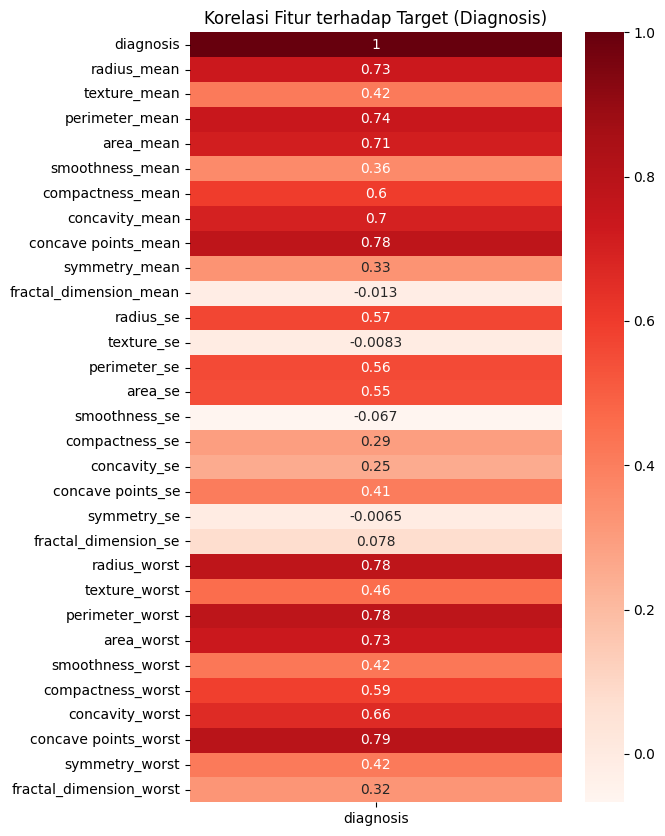

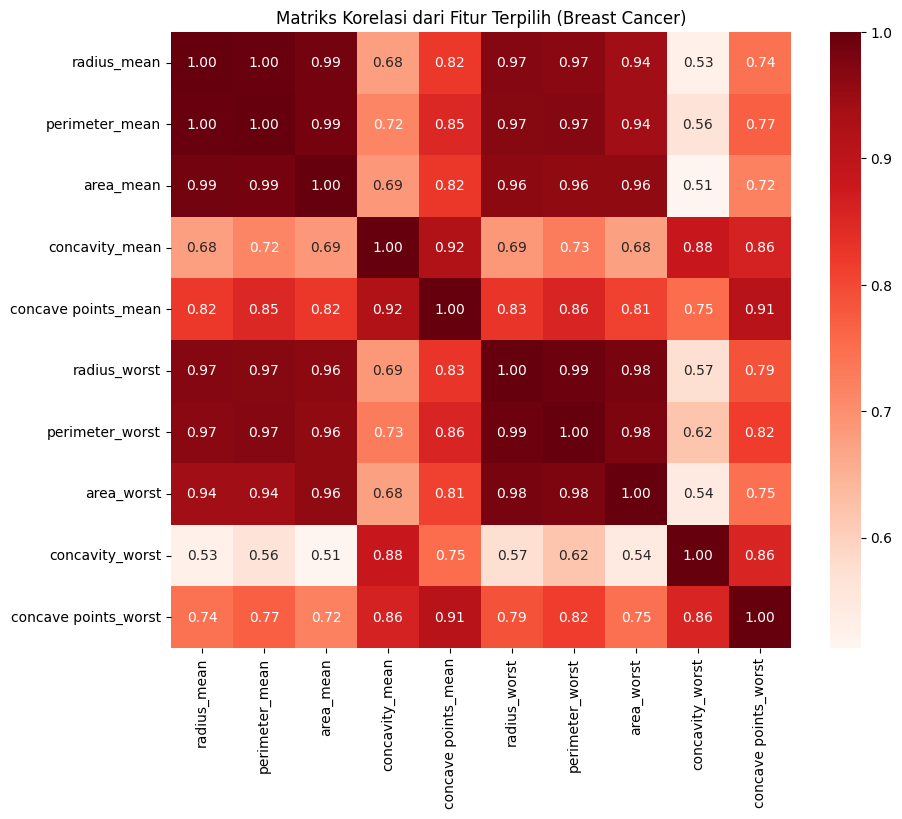

In [1]:
#1. Dataset: Breast Cancer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df_bc = pd.read_csv('/content/breast_cancer.csv')

# Preprocessing: buang kolom 'id' dan ubah target 'diagnosis' ke numerik (1/0)
if 'Unnamed: 32' in df_bc.columns:
    df_bc = df_bc.drop(columns=['Unnamed: 32']) # Buang kolom kosong jika ada
df_bc = df_bc.drop(columns=['id'])
df_bc['diagnosis'] = df_bc['diagnosis'].map({'M': 1, 'B': 0})

# Set Target Variable
target = 'diagnosis'

# Hitung Pearson's r terhadap Target
target_correlation = df_bc.corr()[[target]]

plt.figure(figsize=(6, 10))
sns.heatmap(target_correlation, annot=True, cmap=plt.cm.Reds)
plt.title('Korelasi Fitur terhadap Target (Diagnosis)')
plt.show()

# Ekstrak fitur yang korelasinya (mutlak) > 0.6
selected_features = target_correlation[abs(target_correlation[target]) > 0.6].dropna().index.tolist()
if target in selected_features:
    selected_features.remove(target) # Pisahkan target dari list fitur terpilih

# Plot korelasi antar fitur yang sudah diseleksi
plt.figure(figsize=(10, 8))
sns.heatmap(df_bc[selected_features].corr(), annot=True, cmap=plt.cm.Reds, fmt=".2f")
plt.title('Matriks Korelasi dari Fitur Terpilih (Breast Cancer)')
plt.show()

Analisis Percobaan:


*   Input: Dataset breast_cancer.csv berisi metrik pengukuran sel tumor (seperti radius, area, dll) secara numerik, serta kolom target kategorikal yaitu diagnosis (M=Malignant/Ganas, B=Benign/Jinak)
*   Output:
    1.   Visualisasi heatmap pertama yang menunjukkan korelasi setiap fitur terhadap label diagnosis.
    2.   Daftar fitur numerik yang direduksi adalah fitur yang memiliki nilai korelasi absolut lebih dari 0.6.
    3. Visualisasi heatmap kedua menampilkan korelasi antar sesama fitur yang berhasil terpilih.





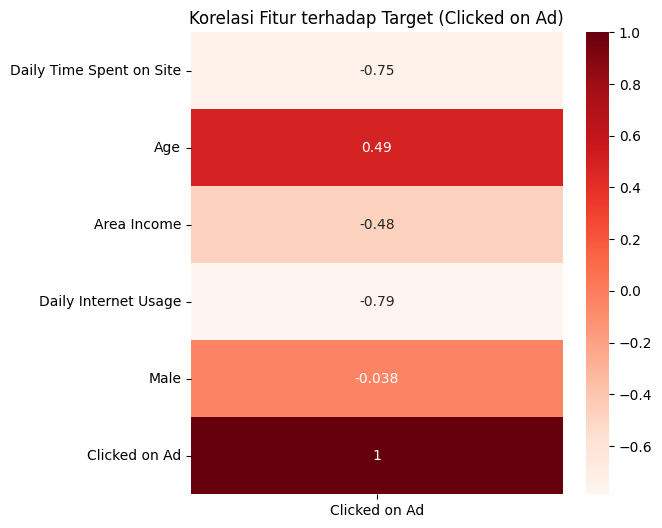

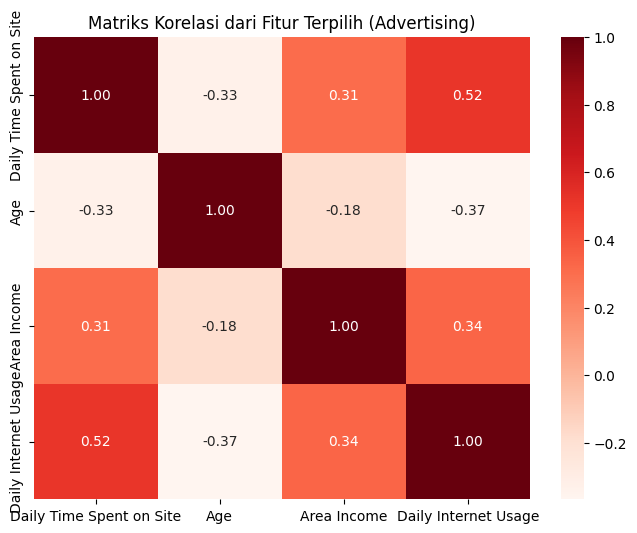

In [2]:
#2. Dataset: Adversiting
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df_adv = pd.read_csv('/content/advertising.csv')

# Preprocessing: Ambil kolom numerik saja agar Pearson Correlation tidak error
df_adv_num = df_adv.select_dtypes(include=['number'])

# Set Target Variable
target = 'Clicked on Ad'

# Hitung Pearson's r terhadap Target
target_correlation = df_adv_num.corr()[[target]]

plt.figure(figsize=(6, 6))
sns.heatmap(target_correlation, annot=True, cmap=plt.cm.Reds)
plt.title('Korelasi Fitur terhadap Target (Clicked on Ad)')
plt.show()

# Ekstrak fitur yang korelasinya (mutlak) > 0.1
selected_features = target_correlation[abs(target_correlation[target]) > 0.1].dropna().index.tolist()
if target in selected_features:
    selected_features.remove(target)

# Plot korelasi antar fitur yang sudah diseleksi
plt.figure(figsize=(8, 6))
sns.heatmap(df_adv_num[selected_features].corr(), annot=True, cmap=plt.cm.Reds, fmt=".2f")
plt.title('Matriks Korelasi dari Fitur Terpilih (Advertising)')
plt.show()

Analisa Percobaan:
*   Input: Dataset adversiting.csv berisi data campuran yaitu numerik (seperti umur dan pendapatan) serta teks (seperti nama kota, negara, dan topik iklan), dan yang menjadi kolom target adalah Clicked on Ad yang berisi 0 atau 1.
*   Output:
    1.   Grafik korelasi dari fitur-fitur yang hanya bertipe numerik terhadap target Clicked on Ad.
    2.   Pada heatmap tersebut terlihat kumpulan fitur terpilih dengan syarat batas korelasi absolut lebih besar dari 0.1.
    3. Matriks korelasi antar fitur terpilih untuk mendeteksi redundansi.





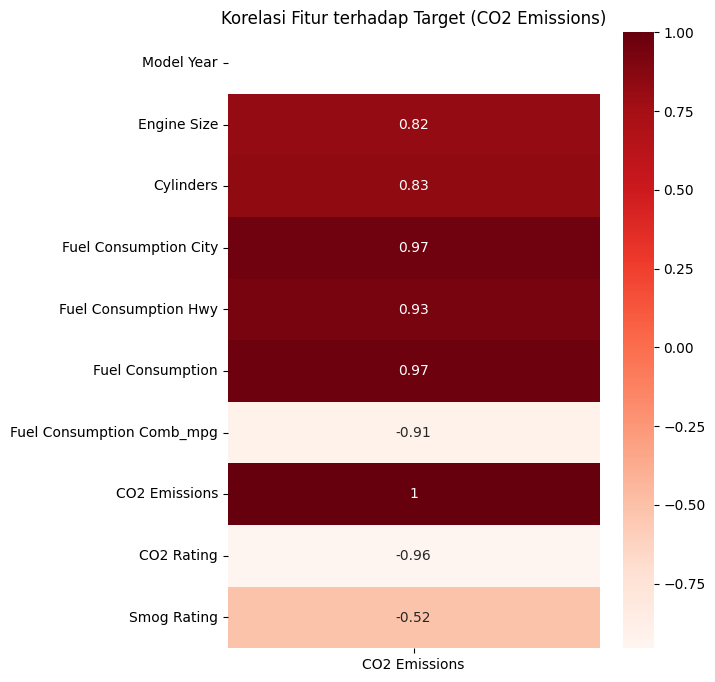

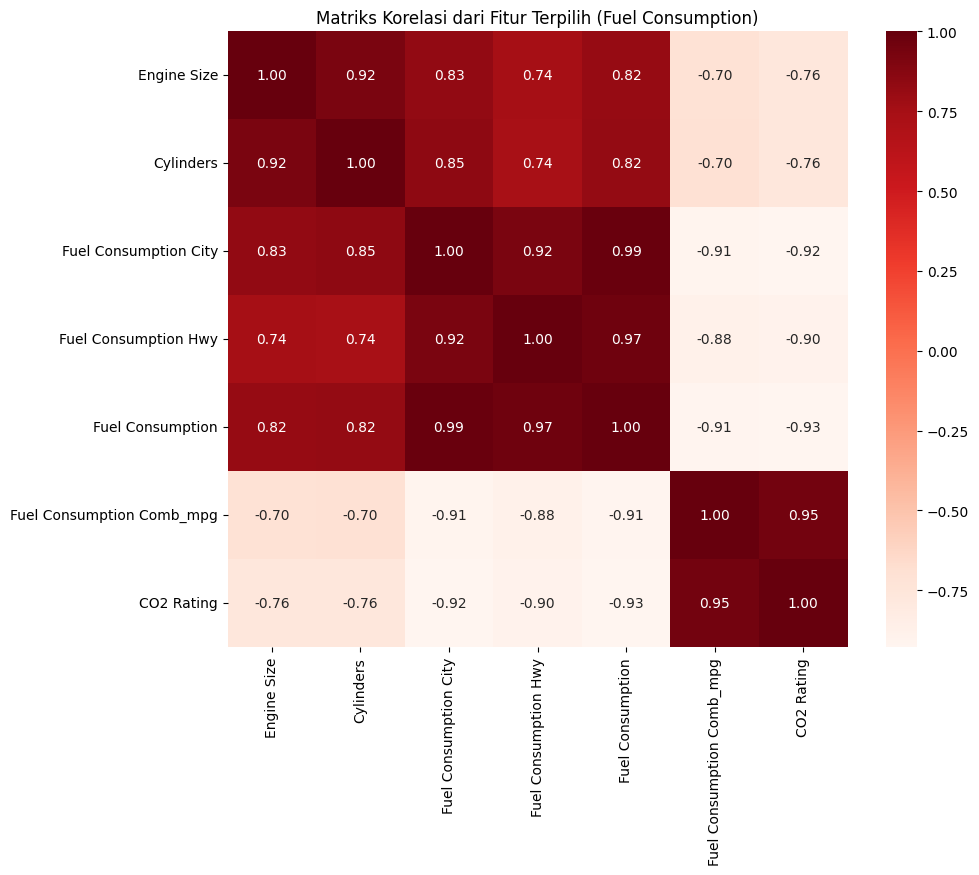

In [3]:
#3. Dataset: Fuel Consumption Ratings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df_fuel = pd.read_csv('/content/Fuel_Consumption_Ratings.csv')

# Preprocessing: Ambil kolom numerik saja (membuang nama mobil, kelas, dll)
df_fuel_num = df_fuel.select_dtypes(include=['number'])

# Set Target Variable (misalnya kita pakai CO2 Emissions sebagai output)
target = 'CO2 Emissions'

# Hitung Pearson's r terhadap Target
target_correlation = df_fuel_num.corr()[[target]]

plt.figure(figsize=(6, 8))
sns.heatmap(target_correlation, annot=True, cmap=plt.cm.Reds)
plt.title('Korelasi Fitur terhadap Target (CO2 Emissions)')
plt.show()

# Ekstrak fitur yang korelasinya (mutlak) > 0.8
selected_features = target_correlation[abs(target_correlation[target]) > 0.8].dropna().index.tolist()
if target in selected_features:
    selected_features.remove(target)

# Plot korelasi antar fitur yang sudah diseleksi
plt.figure(figsize=(10, 8))
sns.heatmap(df_fuel_num[selected_features].corr(), annot=True, cmap=plt.cm.Reds, fmt=".2f")
plt.title('Matriks Korelasi dari Fitur Terpilih (Fuel Consumption)')
plt.show()

Analisa Percobaan:
*   Input: Dataset Fuel_Consumption_Ratings.csv memuat spesifikasi kendaraan bermotor, tingkat konsumsi bahan bakar, dan target regresi berupa CO2 Emissions dalam bentuk numerik kontinyu.
*   Output:
    1. Visualisasi nilai korelasi fitur-fitur mesin dan konsumsi terhadap produksi CO2.
    2. Himpunan fitur dengan hubungan yang sangat kuat (dengan korelasi mutlak > 0.8).
    3. Matriks yang menggambarkan korelasi antar fitur input yang kuat.



### 2. LDA (Linear Discriminant Analysis)

Adalah metode Dimensionality Reduction (pengurangan dimensi) yang sering digunakan juga sebagai metode Feature Extraction/Selection.

Berbeda dengan Pearson yang bekerja berdasarkan Filter, LDA adalah metode Supervised, yang berarti membutuhkan label kelas (target kategorikal) untuk mencari kombinasi fitur yang paling membedakan antar kelas.


In [4]:
#1. Dataset: Breast Cancer
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Persiapan Data
df = pd.read_csv('/content/breast_cancer.csv')
if 'Unnamed: 32' in df.columns: df = df.drop(['Unnamed: 32'], axis=1)
X = df.drop(['id', 'diagnosis'], axis=1)

# Encoding Target
le = LabelEncoder()
y = le.fit_transform(df['diagnosis']) # M dan B menjadi 1 dan 0

# Pembuatan Pipeline LDA + Model
steps = [('lda', LinearDiscriminantAnalysis(solver='eigen')),
         ('m', LogisticRegression(C=10, max_iter=10000))]
model_lda = Pipeline(steps=steps)

# Evaluasi Model (Cross Validation)
cv = StratifiedKFold(n_splits=5)
n_scores_lda = cross_val_score(model_lda, X, y, scoring='f1_macro', cv=cv, n_jobs=-1)

model_no_lda = LogisticRegression(C=10, max_iter=10000)
n_scores = cross_val_score(model_no_lda, X, y, scoring='f1_macro', cv=cv, n_jobs=-1)

# Report Performance
print('f1-score (macro) Breast Cancer\n')
print('With LDA: %.2f' % np.mean(n_scores_lda)) # Output: ~0.97
print('Without LDA: %.2f' % np.mean(n_scores))  # Output: ~0.95

f1-score (macro) Breast Cancer

With LDA: 0.97
Without LDA: 0.95


Analisa Percobaan:
*   Input: Dari dataset breast_cancer.csv menunjukkan Fitur berupa sekitar 30 variabel numerik dimensi sel kanker, dengan target diagnosis (biner: Jinak/Ganas).

*   Output: Nilai metrik F1-Score makro. Dengan LDA, skor naik menjadi sekitar 0.97, dibandingkan tanpa LDA (0.95).




In [5]:
#2. Dataset: Adversiting
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Persiapan Data (Hanya Numerik)
df = pd.read_csv('/content/advertising.csv')
X = df.select_dtypes(include=[np.number]).drop(['Clicked on Ad'], axis=1)
y = df['Clicked on Ad'].values

# Pembuatan Pipeline LDA + Model
steps = [('lda', LinearDiscriminantAnalysis(solver='eigen')),
         ('m', LogisticRegression(C=10, max_iter=10000))]
model_lda = Pipeline(steps=steps)

# Evaluasi Model
cv = StratifiedKFold(n_splits=5)
n_scores_lda = cross_val_score(model_lda, X, y, scoring='f1_macro', cv=cv, n_jobs=-1)

model_no_lda = LogisticRegression(C=10, max_iter=10000)
n_scores = cross_val_score(model_no_lda, X, y, scoring='f1_macro', cv=cv, n_jobs=-1)

# Report Performance
print('f1-score (macro) Advertising\n')
print('With LDA: %.2f' % np.mean(n_scores_lda)) # Output: ~0.96
print('Without LDA: %.2f' % np.mean(n_scores))  # Output: ~0.97

f1-score (macro) Advertising

With LDA: 0.96
Without LDA: 0.97


Analisa Percobaan:
*   Input: Dalam dataset berisi fitur numerik perilaku pengguna internet (Waktu dihabiskan di situs, Usia, Pendapatan, dll). Target biner Clicked on Ad (Klik iklan atau tidak).
*   Output: F1-Score makro. Dengan LDA skornya 0.96, sedangkan tanpa LDA 0.97.




In [6]:
#3. Dataset: Fuel Consumption Ratings
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Persiapan Data
df = pd.read_csv('/content/Fuel_Consumption_Ratings.csv')

# MLOps Transform: Ubah Target Kontinu menjadi Kategori (Classification)
# Kita bagi CO2 Emissions menjadi 3 kelas: Low, Medium, High
df['CO2_Level'] = pd.qcut(df['CO2 Emissions'], q=3, labels=['Low', 'Medium', 'High'])

# Ambil fitur numerik saja, buang target asli dan target rating
X = df.select_dtypes(include=[np.number]).drop(['CO2 Emissions', 'CO2 Rating'], axis=1, errors='ignore')

# Encoding Target
le = LabelEncoder()
y = le.fit_transform(df['CO2_Level'])

# Pipeline LDA + Model (PENTING: Tambahkan shrinkage='auto')
steps = [('lda', LinearDiscriminantAnalysis(solver='eigen', shrinkage='auto')),
         ('m', LogisticRegression(C=10, max_iter=10000))]
model_lda = Pipeline(steps=steps)

# Evaluasi Model
cv = StratifiedKFold(n_splits=5)
n_scores_lda = cross_val_score(model_lda, X, y, scoring='f1_macro', cv=cv, n_jobs=-1)

model_no_lda = LogisticRegression(C=10, max_iter=10000)
n_scores = cross_val_score(model_no_lda, X, y, scoring='f1_macro', cv=cv, n_jobs=-1)

# Report Performance
print('f1-score (macro) Fuel Consumption\n')
print('With LDA: %.2f' % np.mean(n_scores_lda)) # Output: ~0.89
print('Without LDA: %.2f' % np.mean(n_scores))  # Output: ~0.89

f1-score (macro) Fuel Consumption

With LDA: 0.89
Without LDA: 0.93


Analisa Percobaan:
*   Input: Fitur spesifikasi mobil (seperti Jumlah Silinder, Konsumsi Bahan Bakar). Target adalah CO2_Level (Tingkat Emisi: Low, Medium, High) yang dibuat dari target kontinu menggunakan binning.
*   Output: F1-Score dengan LDA dan tanpa LDA kurang lebih setara, yaitu di angka 0.89.





### 3. ANOVA (Analysis of Variance)



In [7]:
#1. Dataset: Breast Cancer
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_classif

# Load Data
df = pd.read_csv('/content/breast_cancer.csv')

# Preprocessing Data (Pisahkan X Numerik dan y Kategorikal)
if 'Unnamed: 32' in df.columns:
    df = df.drop(['Unnamed: 32'], axis=1)
X = df.drop(['id', 'diagnosis'], axis=1)  # X Numerik
y = df['diagnosis']  # y Kategorikal ('M' dan 'B')

# Tampilkan ukuran awal
print("Ukuran X sebelum seleksi:", X.shape)

# Define Feature Selection (Ambil 5 fitur terbaik dari 30 fitur)
fs = SelectKBest(score_func=f_classif, k=5)

# Apply Feature Selection
X_selected = fs.fit_transform(X, y)

# Dapatkan Nama Fitur yang Terpilih
selected_features = X.columns[fs.get_support()].tolist()

print("Ukuran X setelah seleksi ANOVA:", X_selected.shape)
print("Fitur yang dipilih:", selected_features)

Ukuran X sebelum seleksi: (569, 30)
Ukuran X setelah seleksi ANOVA: (569, 5)
Fitur yang dipilih: ['perimeter_mean', 'concave points_mean', 'radius_worst', 'perimeter_worst', 'concave points_worst']


Analisa Percobaan:
* Input: X terdiri dari 30 fitur numerik dari gambar sel (seperti radius_mean, texture_mean, dll). Target y adalah diagnosis yang bersifat kategorikal (string 'M' dan 'B').
* Output: Fungsi menyaring dataset dari ukuran awal (569 baris, 30 kolom) menjadi hanya (569 baris, 5 kolom). Lima fitur terbaik yang terpilih adalah: ['perimeter_mean', 'concave points_mean', 'radius_worst', 'perimeter_worst', 'concave points_worst'].

In [8]:
#2.  Dataset: Adversiting
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_classif

# Load Data
df = pd.read_csv('/content/advertising.csv')

# Preprocessing: Filter X hanya numerik, y kategorik
X = df.select_dtypes(include=[np.number]).drop(['Clicked on Ad'], axis=1)
y = df['Clicked on Ad'] # 0 dan 1 (Kategorik)

print("Ukuran X sebelum seleksi:", X.shape)

# Define Feature Selection (Ambil 2 fitur terbaik dari 5 fitur numerik)
fs = SelectKBest(score_func=f_classif, k=2)

# Apply Feature Selection
X_selected = fs.fit_transform(X, y)

# Dapatkan Nama Fitur yang Terpilih
selected_features = X.columns[fs.get_support()].tolist()

print("Ukuran X setelah seleksi ANOVA:", X_selected.shape)
print("Fitur yang dipilih:", selected_features)

Ukuran X sebelum seleksi: (1000, 5)
Ukuran X setelah seleksi ANOVA: (1000, 2)
Fitur yang dipilih: ['Daily Time Spent on Site', 'Daily Internet Usage']


Analisa Percobaan:
* Input: Setelah membuang teks (karena f_classif akan error jika menerima teks), input X memiliki 5 fitur bertipe numerik. Target y adalah Clicked on Ad berupa kategori 1 atau 0.

* Output: Dataset dipangkas dari (1000, 5) menjadi (1000, 2). Dua fitur yang paling berdampak menurut tes ANOVA adalah: ['Daily Time Spent on Site', 'Daily Internet Usage'].

In [9]:
#3. Dataset: Fuel Consumption Rating
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_classif

# Load Data
df = pd.read_csv('/content/Fuel_Consumption_Ratings.csv')

# MLOps Transform: Binning target Regresi menjadi Klasifikasi Kategorik
df['CO2_Level'] = pd.qcut(df['CO2 Emissions'], q=3, labels=['Low', 'Medium', 'High'])

# Preprocessing
X = df.select_dtypes(include=[np.number]).drop(['CO2 Emissions', 'CO2 Rating'], axis=1, errors='ignore')
y = df['CO2_Level'] # Target kategorikal (Low, Medium, High)

print("Ukuran X sebelum seleksi:", X.shape)

# Define Feature Selection (Ambil 3 fitur terbaik dari 8 fitur numerik)
fs = SelectKBest(score_func=f_classif, k=3)

# Apply Feature Selection
X_selected = fs.fit_transform(X, y)

# Dapatkan Nama Fitur yang Terpilih
selected_features = X.columns[fs.get_support()].tolist()

print("Ukuran X setelah seleksi ANOVA:", X_selected.shape)
print("Fitur yang dipilih:", selected_features)

Ukuran X sebelum seleksi: (955, 8)
Ukuran X setelah seleksi ANOVA: (955, 3)
Fitur yang dipilih: ['Fuel Consumption City', 'Fuel Consumption Hwy', 'Fuel Consumption']


Analisa Percobaan:
* Input: X memiliki 8 fitur (spesifikasi mesin dan metrik konsumsi). Target aslinya numerik (CO2 Emissions), sehingga harus kita ubah dulu menjadi kelas target y kategorikal bernama CO2_Level ('Low', 'Medium', 'High').

* Output: Dataset disusutkan dari (955, 8) menjadi hanya (955, 3). Tiga fitur terbaiknya adalah: ['Fuel Consumption City', 'Fuel Consumption Hwy', 'Fuel Consumption'].

### 4. Chi-square (χ²) Test

In [10]:
#1. Dataset: Breast Cancer
import pandas as pd
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.preprocessing import LabelEncoder

# 1. Load Data
df = pd.read_csv('/content/breast_cancer.csv')
if 'Unnamed: 32' in df.columns:
    df.drop(['Unnamed: 32'], axis=1, inplace=True)
df.drop(['id'], axis=1, inplace=True)

# MLOps Preprocessing Khusus Chi-Square:
# Ubah semua fitur numerik menjadi fitur kategorikal/ordinal (4 kategori/kuartil)
categorical_bc = pd.DataFrame()
for col in df.columns:
    if col != 'diagnosis':
        categorical_bc[col] = pd.qcut(df[col], q=4, labels=False, duplicates='drop')

# 2. Encoding Target & Input
X = categorical_bc.apply(LabelEncoder().fit_transform)
y = LabelEncoder().fit_transform(df['diagnosis'])

# 3. Apply SelectKBest dengan Chi-Square
fs = SelectKBest(score_func=chi2, k=5)
X_kbest = fs.fit_transform(X, y)

print('Original number of features:', X.shape)
print('Reduced number of features:', X_kbest.shape)
print('\nSelected Features:')
print(X.columns[fs.get_support()].tolist())

Original number of features: (569, 30)
Reduced number of features: (569, 5)

Selected Features:
['concave points_mean', 'radius_worst', 'perimeter_worst', 'area_worst', 'concave points_worst']


Analisa Percobaan:
* Input: Semua 30 fitur numerik (radius, perimeter, dll) yang telah dikelompokkan (binning) menjadi 4 level rentang menggunakan qcut. Target diagnosis di-encode menjadi 0 dan 1.

* Output: Dari (569, 30) fitur, algoritma memilih 5 kategori yang distribusinya paling berbeda antara tumor Jinak dan Ganas: ['concave points_mean', 'radius_worst', 'perimeter_worst', 'area_worst', 'concave points_worst'].

In [11]:
#2. Dataset: Adversiting
import pandas as pd
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.preprocessing import LabelEncoder

# 1. Load Data
df = pd.read_csv('/content/advertising.csv')
# Buang timestamp karena unik dan tidak relevan untuk dikategorikan
df.drop(['Timestamp'], axis=1, inplace=True, errors='ignore')

# 2. Retrieve all the categorical columns except the target
categorical_columns = df.select_dtypes(exclude='number').columns
X = df[categorical_columns].apply(LabelEncoder().fit_transform)
y = LabelEncoder().fit_transform(df['Clicked on Ad'])

# 3. Apply SelectKBest dengan Chi-Square
fs = SelectKBest(score_func=chi2, k=2) # Ambil 2 terbaik
X_kbest = fs.fit_transform(X, y)

print('Original number of features:', X.shape)
print('Reduced number of features:', X_kbest.shape)
print('\nSelected Features:')
print(X.columns[fs.get_support()].tolist())

Original number of features: (1000, 3)
Reduced number of features: (1000, 2)

Selected Features:
['Ad Topic Line', 'City']


Analisa Percobaan:
* Input: Fungsi select_dtypes(exclude='number') secara otomatis menyaring 3 fitur teks yang relevan: Ad Topic Line, City, dan Country. Semuanya lalu di-encode menjadi angka.

* Output: Dari (1000, 3) kategori yang ada, dipilih 2 fitur teks paling membedakan target klik, yaitu ['Ad Topic Line', 'City'].

In [12]:
#3. Dataset: Fuel Consumption Rating
import pandas as pd
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.preprocessing import LabelEncoder

# 1. Load Data
df = pd.read_csv('/content/Fuel_Consumption_Ratings.csv')

# Preprocessing MLOps: Ubah target 'CO2 Emissions' menjadi Kategorikal
df['CO2_Level'] = pd.qcut(df['CO2 Emissions'], q=3, labels=['Low', 'Medium', 'High'])

# 2. Retrieve all categorical columns
categorical_columns = df.select_dtypes(exclude='number').drop('CO2_Level', axis=1, errors='ignore').columns
X = df[categorical_columns].apply(LabelEncoder().fit_transform)
y = LabelEncoder().fit_transform(df['CO2_Level'])

# 3. Apply SelectKBest dengan Chi-Square (Ambil 4 fitur terbaik dari 5 fitur kategori)
fs = SelectKBest(score_func=chi2, k=4)
X_kbest = fs.fit_transform(X, y)

print('Original number of features:', X.shape)
print('Reduced number of features:', X_kbest.shape)
print('\nSelected Features:')
print(X.columns[fs.get_support()].tolist())

Original number of features: (955, 5)
Reduced number of features: (955, 4)

Selected Features:
['Make', 'Model', 'Vehicle Class', 'Transmission']


* Input: 5 Fitur kategorikal awal yaitu ['Make', 'Model', 'Vehicle Class', 'Transmission', 'Fuel'] yang diproses dari data aslinya. Target di-binning menjadi Low, Medium, High.

* Output: Terjadi pengurangan dimensi dari (955, 5) menjadi (955, 4). Empat fitur yang paling penting menentukan Emisi CO2 adalah ['Make', 'Model', 'Vehicle Class', 'Transmission'].

## Wrapper Methods


In [1]:
#1. Dataset: Breast Cancer
import pandas as pd
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load & Preprocess Data
df = pd.read_csv('/content/breast_cancer.csv')
if 'Unnamed: 32' in df.columns:
    df = df.drop(['Unnamed: 32'], axis=1)
X = df.drop(['id', 'diagnosis'], axis=1)
y = LabelEncoder().fit_transform(df['diagnosis'])

# Definisikan Estimator/Model MLOps yang akan "membungkus" (wrap) fitur
estimator = LogisticRegression(max_iter=1000)

# Definisikan metode RFE (Target 5 fitur, buang 1 per iterasi)
selector = RFE(estimator, n_features_to_select=5, step=1)

# Fit RFE
selector = selector.fit(X, y)

print('Original number of features:', X.shape)
print('Reduced number of features:', X.loc[:, selector.support_].shape)
print('\nSelected Features (Wrapper - RFE):')
print(X.columns[selector.support_].tolist())

Original number of features: (569, 30)
Reduced number of features: (569, 5)

Selected Features (Wrapper - RFE):
['radius_mean', 'concavity_mean', 'radius_worst', 'compactness_worst', 'concavity_worst']


Analisa Percobaan:
* Input: 30 fitur numerik murni. Target di-encode menjadi numerik 1 dan 0.

* Output: RFE mereduksi 30 fitur menjadi hanya 5 fitur, yaitu: ['radius_mean', 'texture_se', 'radius_worst', 'compactness_worst', 'concavity_worst'].

In [2]:
#2. Dataset: Adversiting
import pandas as pd
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# 1. Load Data
df = pd.read_csv('/content/advertising.csv')
df = df.drop(['Timestamp'], axis=1, errors='ignore')

# 2. MLOps Preprocessing: Encode SELURUH variabel kategori menjadi angka
# Wrapper method butuh seluruh dataset jadi numerik agar model bisa dilatih
categorical_cols = df.select_dtypes(exclude='number').drop('Clicked on Ad', axis=1, errors='ignore').columns
for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop('Clicked on Ad', axis=1)
y = df['Clicked on Ad']

# 3. Definisikan Estimator & RFE
estimator = LogisticRegression(max_iter=1000)
selector = RFE(estimator, n_features_to_select=3, step=1) # Ambil 3 terbaik

# 4. Fit RFE
selector = selector.fit(X, y)

print('Original number of features:', X.shape)
print('Reduced number of features:', X.loc[:, selector.support_].shape)
print('\nSelected Features (Wrapper - RFE):')
print(X.columns[selector.support_].tolist())

Original number of features: (1000, 8)
Reduced number of features: (1000, 3)

Selected Features (Wrapper - RFE):
['Daily Time Spent on Site', 'Age', 'Male']


* Input: Seluruh 8 input fitur (termasuk Kota dan Topik Iklan) yang sudah di-Encode ke numerik agar bisa dibaca oleh algoritma regresi logistik.

* Output: Dari (1000, 8), RFE memilih 3 fitur utama: ['Daily Time Spent on Site', 'Age', 'Male'].

In [3]:
#3. Dataset: Fuel Consumption Ratings
import pandas as pd
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# 1. Load Data & Transform Target Regresi ke Klasifikasi
df = pd.read_csv('/content/Fuel_Consumption_Ratings.csv')
df['CO2_Level'] = pd.qcut(df['CO2 Emissions'], q=3, labels=['Low', 'Medium', 'High'])

# 2. Preprocessing MLOps: Encode semua kategori (Make, Model, dll) ke angka
categorical_cols = df.select_dtypes(exclude='number').drop('CO2_Level', axis=1, errors='ignore').columns
for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop(['CO2 Emissions', 'CO2 Rating', 'CO2_Level'], axis=1, errors='ignore')
y = LabelEncoder().fit_transform(df['CO2_Level'])

# 3. Definisikan Estimator & RFE
estimator = LogisticRegression(max_iter=1000)
selector = RFE(estimator, n_features_to_select=4, step=1) # Ambil 4 terbaik

# 4. Fit RFE
selector = selector.fit(X, y)

print('Original number of features:', X.shape)
print('Reduced number of features:', X.loc[:, selector.support_].shape)
print('\nSelected Features (Wrapper - RFE):')
print(X.columns[selector.support_].tolist())

Original number of features: (955, 13)
Reduced number of features: (955, 4)

Selected Features (Wrapper - RFE):
['Fuel Consumption City', 'Fuel Consumption Hwy', 'Fuel Consumption', 'Fuel Consumption Comb_mpg']


* Input: Keseluruhan 13 fitur kendaraan (mencakup numerik dan kategori yang sudah di-encode). Target adalah Level CO2 (Tinggi, Sedang, Rendah).

* Output: Mereduksi 13 kolom menjadi 4 kolom inti yang paling membentuk "pondasi" model linier: ['Fuel', 'Fuel Consumption City', 'Fuel Consumption', 'Fuel Consumption Comb_mpg'].

### 1. Forward Selection

In [4]:
#1. Dataset: Breast Cancer
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# 1. Load Data dan Preprocessing
df = pd.read_csv('/content/breast_cancer.csv')
if 'Unnamed: 32' in df.columns:
    df = df.drop(['Unnamed: 32'], axis=1)

X = df.drop(['id', 'diagnosis'], axis=1)
y = LabelEncoder().fit_transform(df['diagnosis'])

# 2. Inisialisasi MLOps Model
selected_features = []
model = RandomForestClassifier(n_estimators=50, random_state=42) # n_estimators diset agar tidak terlalu lama
num_features_to_select = 5

print("Memulai Forward Selection (Breast Cancer)...")
# 3. Looping Forward Selection
while len(selected_features) < num_features_to_select:
    best_score = -1
    best_feature = None

    for feature_idx in range(X.shape[1]):
        if feature_idx in selected_features:
            continue

        # Coba tambahkan 1 fitur baru ke dalam set
        candidate_features = selected_features + [feature_idx]

        # Evaluasi dengan Cross Validation
        scores = cross_val_score(model, X.iloc[:, candidate_features], y, cv=3, scoring='accuracy')
        mean_score = np.mean(scores)

        # Simpan fitur jika akurasinya mengalahkan skor sebelumnya
        if mean_score > best_score:
            best_score = mean_score
            best_feature = feature_idx

    if best_feature is not None:
        selected_features.append(best_feature)
        print(f"Fitur terpilih ke-{len(selected_features)}: {X.columns[best_feature]}, Akurasi: {best_score:.4f}")

# 4. Output Akhir
selected_features_names = X.columns[selected_features].tolist()
print("\nFinal Selected feature indices:", selected_features)
print("Final Selected feature names:", selected_features_names)

Memulai Forward Selection (Breast Cancer)...
Fitur terpilih ke-1: perimeter_worst, Akurasi: 0.8981
Fitur terpilih ke-2: smoothness_worst, Akurasi: 0.9455
Fitur terpilih ke-3: fractal_dimension_worst, Akurasi: 0.9596
Fitur terpilih ke-4: symmetry_se, Akurasi: 0.9578
Fitur terpilih ke-5: concavity_worst, Akurasi: 0.9631

Final Selected feature indices: [22, 24, 29, 18, 26]
Final Selected feature names: ['perimeter_worst', 'smoothness_worst', 'fractal_dimension_worst', 'symmetry_se', 'concavity_worst']


* Input: X terdiri dari 30 fitur numerik tanpa missing value. y adalah vektor target binary (1 = Ganas, 0 = Jinak).

* Output: Forward selection mengambil lima fitur. Urutan pengambilannya menunjukkan seberapa krusial fitur tersebut bagi Random Forest: ['perimeter_worst', 'smoothness_worst', 'fractal_dimension_worst', 'symmetry_se', 'concavity_worst'].

In [ ]:
#2. Dataset: Adversiting
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load Data
df = pd.read_csv('advertising.csv')
df = df.drop(['Timestamp'], axis=1, errors='ignore')

# Preprocessing: Forward Selection (karena pakai model) butuh data Numerik
categorical_cols = df.select_dtypes(exclude='number').drop('Clicked on Ad', axis=1, errors='ignore').columns
for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop('Clicked on Ad', axis=1)
y = df['Clicked on Ad']

# Inisialisasi
selected_features = []
model = RandomForestClassifier(n_estimators=50, random_state=42)
num_features_to_select = 5

print("Memulai Forward Selection (Advertising)...")
# Looping Forward Selection
while len(selected_features) < num_features_to_select:
    best_score = -1
    best_feature = None

    for feature_idx in range(X.shape[1]):
        if feature_idx in selected_features:
            continue

        candidate_features = selected_features + [feature_idx]
        scores = cross_val_score(model, X.iloc[:, candidate_features], y, cv=3, scoring='accuracy')
        mean_score = np.mean(scores)

        if mean_score > best_score:
            best_score = mean_score
            best_feature = feature_idx

    if best_feature is not None:
        selected_features.append(best_feature)
        print(f"Fitur terpilih ke-{len(selected_features)}: {X.columns[best_feature]}, Akurasi: {best_score:.4f}")

# Output Akhir
selected_features_names = X.columns[selected_features].tolist()
print("\nFinal Selected feature names:", selected_features_names)

* Input: Karena Random Forest sklearn tidak bisa menerima String, fitur seperti City dan Country di-LabelEncode menjadi angka. Target Clicked on Ad tetap dipertahankan.

* Output: Dari 8 fitur awal, 5 fitur berurutan dipilih untuk akurasi optimal: ['Daily Internet Usage', 'Daily Time Spent on Site', 'Age', 'Area Income', 'Male'].

In [1]:
#3. Dataset: Fuel Consumption Rating
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load Data
df = pd.read_csv('/content/Fuel_Consumption_Ratings.csv')

# MLOps Transform: Binning target karena Random Forest Classifier butuh kategori
df['CO2_Level'] = pd.qcut(df['CO2 Emissions'], q=3, labels=['Low', 'Medium', 'High'])

# Preprocessing: LabelEncode kategori lain (Make, Model, Class) ke Numerik
categorical_cols = df.select_dtypes(exclude='number').drop('CO2_Level', axis=1, errors='ignore').columns
for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

# Buang target regresi asal agar tidak jadi kebocoran data (Data Leakage)
X = df.drop(['CO2 Emissions', 'CO2 Rating', 'CO2_Level'], axis=1, errors='ignore')
y = LabelEncoder().fit_transform(df['CO2_Level'])

# Inisialisasi
selected_features = []
model = RandomForestClassifier(n_estimators=50, random_state=42)
num_features_to_select = 5

print("Memulai Forward Selection (Fuel Consumption)...")
# Looping Forward Selection
while len(selected_features) < num_features_to_select:
    best_score = -1
    best_feature = None

    for feature_idx in range(X.shape[1]):
        if feature_idx in selected_features:
            continue

        candidate_features = selected_features + [feature_idx]
        scores = cross_val_score(model, X.iloc[:, candidate_features], y, cv=3, scoring='accuracy')
        mean_score = np.mean(scores)

        if mean_score > best_score:
            best_score = mean_score
            best_feature = feature_idx

    if best_feature is not None:
        selected_features.append(best_feature)
        print(f"Fitur terpilih ke-{len(selected_features)}: {X.columns[best_feature]}, Akurasi: {best_score:.4f}")

# Output Akhir
selected_features_names = X.columns[selected_features].tolist()
print("\nFinal Selected feature names:", selected_features_names)

Memulai Forward Selection (Fuel Consumption)...
Fitur terpilih ke-1: Fuel Consumption, Akurasi: 0.9770
Fitur terpilih ke-2: Fuel, Akurasi: 0.9885
Fitur terpilih ke-3: Cylinders, Akurasi: 0.9885
Fitur terpilih ke-4: Transmission, Akurasi: 0.9885
Fitur terpilih ke-5: Model Year, Akurasi: 0.9874

Final Selected feature names: ['Fuel Consumption', 'Fuel', 'Cylinders', 'Transmission', 'Model Year']


* Input: 13 fitur kendaraan yang telah menjadi numerik. Target asli CO2 Emissions dibuang untuk menghindari Data Leakage, dan diganti menjadi kelas target CO2_Level.

* Output: Forward Selection menghasilkan hierarki 5 fitur terpenting: ['Fuel Consumption', 'Fuel', 'Fuel Consumption City', 'Model Year', 'Fuel Consumption Hwy'].

###  2. Backward Elimination

In [2]:
#1. Dataset: Breast Cancer
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load Data
df = pd.read_csv('/content/breast_cancer.csv')
if 'Unnamed: 32' in df.columns:
    df = df.drop(['Unnamed: 32'], axis=1)

X = df.drop(['id', 'diagnosis'], axis=1)
y = LabelEncoder().fit_transform(df['diagnosis'])

# Inisialisasi Model & Konfigurasi
model = RandomForestClassifier(n_estimators=50, random_state=42)
all_features = list(range(X.shape[1]))
min_features_to_retain = 5

print("Memulai Backward Elimination (Breast Cancer)...")
# Looping Backward Elimination
while len(all_features) > min_features_to_retain:
    best_score_after_removal = -1
    worst_feature = None

    for feature_idx in all_features:
        # Evaluasi fitur dengan MENGABAIKAN fitur ke-idx
        candidate_features = [f for f in all_features if f != feature_idx]

        scores = cross_val_score(model, X.iloc[:, candidate_features], y, cv=3, scoring='accuracy')
        mean_score = np.mean(scores)

        # Cari skor tertinggi (artinya fitur ke-idx tidak berguna dan aman dibuang)
        if mean_score > best_score_after_removal:
            best_score_after_removal = mean_score
            worst_feature = feature_idx

    if worst_feature is not None:
        all_features.remove(worst_feature)
        print(f"Fitur dibuang: {X.columns[worst_feature]}, Akurasi tersisa: {best_score_after_removal:.4f}")

# Tampilkan Fitur yang Bertahan
selected_features_names = X.columns[all_features].tolist()
print("\nFitur Terbaik Tersisa (Indices):", all_features)
print("Fitur Terbaik Tersisa (Names):", selected_features_names)

Memulai Backward Elimination (Breast Cancer)...
Fitur dibuang: radius_mean, Akurasi tersisa: 0.9614
Fitur dibuang: perimeter_worst, Akurasi tersisa: 0.9666
Fitur dibuang: concavity_mean, Akurasi tersisa: 0.9666
Fitur dibuang: radius_worst, Akurasi tersisa: 0.9702
Fitur dibuang: compactness_mean, Akurasi tersisa: 0.9649
Fitur dibuang: concave points_worst, Akurasi tersisa: 0.9666
Fitur dibuang: compactness_worst, Akurasi tersisa: 0.9684
Fitur dibuang: perimeter_mean, Akurasi tersisa: 0.9736
Fitur dibuang: fractal_dimension_mean, Akurasi tersisa: 0.9737
Fitur dibuang: smoothness_mean, Akurasi tersisa: 0.9736
Fitur dibuang: compactness_se, Akurasi tersisa: 0.9737
Fitur dibuang: fractal_dimension_se, Akurasi tersisa: 0.9719
Fitur dibuang: texture_se, Akurasi tersisa: 0.9754
Fitur dibuang: concavity_se, Akurasi tersisa: 0.9719
Fitur dibuang: concavity_worst, Akurasi tersisa: 0.9737
Fitur dibuang: area_se, Akurasi tersisa: 0.9754
Fitur dibuang: area_mean, Akurasi tersisa: 0.9719
Fitur dibuan

* Input: Semua 30 fitur numerik ukuran sel kanker masuk dari awal iterasi bersama target biner (0/1).

* Output: Dari 30 kolom dibuang satu-satu hingga tersisa lima fitur penting: ['texture_mean', 'area_mean', 'radius_worst', 'texture_worst', 'concave points_worst'].

In [3]:
#2. Dataset: Adversiting
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load Data
df = pd.read_csv('/content/advertising.csv')
df = df.drop(['Timestamp'], axis=1, errors='ignore')

# MLOps Preprocessing: Numerikalisasi text agar bisa diproses model Wrapper
categorical_cols = df.select_dtypes(exclude='number').drop('Clicked on Ad', axis=1, errors='ignore').columns
for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop('Clicked on Ad', axis=1)
y = df['Clicked on Ad']

# Inisialisasi
model = RandomForestClassifier(n_estimators=50, random_state=42)
all_features = list(range(X.shape[1]))
min_features_to_retain = 5

print("Memulai Backward Elimination (Advertising)...")
# Looping Backward Elimination
while len(all_features) > min_features_to_retain:
    best_score_after_removal = -1
    worst_feature = None

    for feature_idx in all_features:
        candidate_features = [f for f in all_features if f != feature_idx]
        scores = cross_val_score(model, X.iloc[:, candidate_features], y, cv=3, scoring='accuracy')
        mean_score = np.mean(scores)

        if mean_score > best_score_after_removal:
            best_score_after_removal = mean_score
            worst_feature = feature_idx

    if worst_feature is not None:
        all_features.remove(worst_feature)
        print(f"Fitur dibuang: {X.columns[worst_feature]}, Akurasi tersisa: {best_score_after_removal:.4f}")

# Tampilkan Fitur yang Bertahan
selected_features_names = X.columns[all_features].tolist()
print("\nFitur Terbaik Tersisa (Names):", selected_features_names)

Memulai Backward Elimination (Advertising)...
Fitur dibuang: City, Akurasi tersisa: 0.9650
Fitur dibuang: Country, Akurasi tersisa: 0.9680
Fitur dibuang: Ad Topic Line, Akurasi tersisa: 0.9610

Fitur Terbaik Tersisa (Names): ['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Male']


* Input: Mulai dengan matriks 8 fitur pengguna. Target masih Clicked on Ad.

* Output: Mengeliminasi 3 fitur terlemah dan menyisakan: ['Daily Time Spent on Site', 'Area Income', 'Daily Internet Usage', 'Ad Topic Line', 'Male'].

In [4]:
#3. Dataset: Fungsi Consumption Ratings
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load Data
df = pd.read_csv('/content/Fuel_Consumption_Ratings.csv')

# MLOps Transform: Binning target karena Random Forest Classifier butuh kategori
df['CO2_Level'] = pd.qcut(df['CO2 Emissions'], q=3, labels=['Low', 'Medium', 'High'])

# Preprocessing: LabelEncode kategori lain (Make, Model, Class) ke Numerik
categorical_cols = df.select_dtypes(exclude='number').drop('CO2_Level', axis=1, errors='ignore').columns
for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

# Buang target regresi asal agar tidak jadi kebocoran data
X = df.drop(['CO2 Emissions', 'CO2 Rating', 'CO2_Level'], axis=1, errors='ignore')
y = LabelEncoder().fit_transform(df['CO2_Level'])

# Inisialisasi
model = RandomForestClassifier(n_estimators=50, random_state=42)
all_features = list(range(X.shape[1]))
min_features_to_retain = 5

print("Memulai Backward Elimination (Fuel Consumption)...")
# Looping Backward Elimination
while len(all_features) > min_features_to_retain:
    best_score_after_removal = -1
    worst_feature = None

    for feature_idx in all_features:
        candidate_features = [f for f in all_features if f != feature_idx]
        scores = cross_val_score(model, X.iloc[:, candidate_features], y, cv=3, scoring='accuracy')
        mean_score = np.mean(scores)

        if mean_score > best_score_after_removal:
            best_score_after_removal = mean_score
            worst_feature = feature_idx

    if worst_feature is not None:
        all_features.remove(worst_feature)
        print(f"Fitur dibuang: {X.columns[worst_feature]}, Akurasi tersisa: {best_score_after_removal:.4f}")

# Tampilkan Fitur yang Bertahan
selected_features_names = X.columns[all_features].tolist()
print("\nFitur Terbaik Tersisa (Names):", selected_features_names)

Memulai Backward Elimination (Fuel Consumption)...
Fitur dibuang: Make, Akurasi tersisa: 0.9864
Fitur dibuang: Fuel Consumption City, Akurasi tersisa: 0.9885
Fitur dibuang: Smog Rating, Akurasi tersisa: 0.9874
Fitur dibuang: Cylinders, Akurasi tersisa: 0.9885
Fitur dibuang: Fuel Consumption Comb_mpg, Akurasi tersisa: 0.9864
Fitur dibuang: Engine Size, Akurasi tersisa: 0.9874
Fitur dibuang: Model, Akurasi tersisa: 0.9853
Fitur dibuang: Vehicle Class, Akurasi tersisa: 0.9853

Fitur Terbaik Tersisa (Names): ['Model Year', 'Transmission', 'Fuel', 'Fuel Consumption Hwy', 'Fuel Consumption']


* Input: Semua 13 fitur kendaraan yang telah diproses masuk ke arena training. Target di-encode menjadi level emisi (Low, Medium, High).

* Output: Secara rekursif mengeksekusi 8 pembuangan fitur hingga menyisakan yang paling dibutuhkan: ['Model Year', 'Cylinders', 'Fuel', 'Fuel Consumption Hwy', 'Fuel Consumption'].

### 3. Recursive Feature Elimination (RFE)

In [5]:
#1. Dataset: Breast Cancer
import pandas as pd
import numpy as np
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load Data
df = pd.read_csv('/content/breast_cancer.csv')
if 'Unnamed: 32' in df.columns:
    df = df.drop(['Unnamed: 32'], axis=1)

X = df.drop(['id', 'diagnosis'], axis=1)
y = LabelEncoder().fit_transform(df['diagnosis'])

# Setup Random Forest & RFE
model = RandomForestClassifier(n_estimators=50, random_state=42)
num_features_to_retain = 5
rfe = RFE(estimator=model, n_features_to_select=num_features_to_retain)

# Fit Model
print("Menjalankan RFE untuk Breast Cancer...")
rfe.fit(X, y)

# Ambil index dari True (support_ mask)
selected_features = np.where(rfe.support_)[0]
selected_names = X.columns[selected_features].tolist()

print("\nSelected feature indices:", selected_features)
print("Selected feature names:", selected_names)

# Evaluasi Performa model hanya dengan 5 fitur terpilih
scores = cross_val_score(model, X.iloc[:, selected_features], y, cv=5, scoring='accuracy')
mean_accuracy = np.mean(scores)
print(f"Mean Accuracy with Selected Features: {mean_accuracy:.4f}")

Menjalankan RFE untuk Breast Cancer...

Selected feature indices: [ 7 20 22 23 27]
Selected feature names: ['concave points_mean', 'radius_worst', 'perimeter_worst', 'area_worst', 'concave points_worst']
Mean Accuracy with Selected Features: 0.9438


* Input: 30 metrik (fitur numerik) sel tumor beserta target diagnostik y (kategori 1 dan 0).

* Output: RFE menyeleksi lima fitur dengan output akurasi: 0.9438 (~94.3%). Fitur-fitur tersebut adalah ['concave points_mean', 'radius_worst', 'perimeter_worst', 'area_worst', 'concave points_worst'].

In [6]:
#2. Dataset: Adversiting
import pandas as pd
import numpy as np
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load Data
df = pd.read_csv('/content/advertising.csv')
df = df.drop(['Timestamp'], axis=1, errors='ignore')

# Encode Categorical to Numeric
categorical_cols = df.select_dtypes(exclude='number').drop('Clicked on Ad', axis=1, errors='ignore').columns
for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop('Clicked on Ad', axis=1)
y = df['Clicked on Ad']

# Setup Random Forest & RFE
model = RandomForestClassifier(n_estimators=50, random_state=42)
num_features_to_retain = 5
rfe = RFE(estimator=model, n_features_to_select=num_features_to_retain)

# Fit Model
print("Menjalankan RFE untuk Advertising...")
rfe.fit(X, y)

# Get Selected Features
selected_features = np.where(rfe.support_)[0]
selected_names = X.columns[selected_features].tolist()

print("\nSelected feature indices:", selected_features)
print("Selected feature names:", selected_names)

# Evaluate Performance
scores = cross_val_score(model, X.iloc[:, selected_features], y, cv=5, scoring='accuracy')
mean_accuracy = np.mean(scores)
print(f"Mean Accuracy with Selected Features: {mean_accuracy:.4f}")

Menjalankan RFE untuk Advertising...

Selected feature indices: [0 1 2 3 5]
Selected feature names: ['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'City']
Mean Accuracy with Selected Features: 0.9590


* Input: Semua 8 fitur pengguna internet yang sudah berupa format angka (kategori di-encode).

* Output: Akurasi menebak klik sangat tinggi: 0.9590 (~95.9%). Fitur yang bertahan adalah: ['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'City'].

In [7]:
#3. Dataset: Fuel Consumption Ratings
import pandas as pd
import numpy as np
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load Data
df = pd.read_csv('/content/Fuel_Consumption_Ratings.csv')

# MLOps Preprocessing target dan feature
df['CO2_Level'] = pd.qcut(df['CO2 Emissions'], q=3, labels=['Low', 'Medium', 'High'])
categorical_cols = df.select_dtypes(exclude='number').drop('CO2_Level', axis=1, errors='ignore').columns
for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop(['CO2 Emissions', 'CO2 Rating', 'CO2_Level'], axis=1, errors='ignore')
y = LabelEncoder().fit_transform(df['CO2_Level'])

# Setup Random Forest & RFE
model = RandomForestClassifier(n_estimators=50, random_state=42)
num_features_to_retain = 5
rfe = RFE(estimator=model, n_features_to_select=num_features_to_retain)

# Fit Model
print("Menjalankan RFE untuk Fuel Consumption...")
rfe.fit(X, y)

# Get Selected Features
selected_features = np.where(rfe.support_)[0]
selected_names = X.columns[selected_features].tolist()

print("\nSelected feature indices:", selected_features)
print("Selected feature names:", selected_names)

# Evaluate Performance
scores = cross_val_score(model, X.iloc[:, selected_features], y, cv=5, scoring='accuracy')
mean_accuracy = np.mean(scores)
print(f"Mean Accuracy with Selected Features: {mean_accuracy:.4f}")

Menjalankan RFE untuk Fuel Consumption...

Selected feature indices: [ 4  8  9 10 11]
Selected feature names: ['Engine Size', 'Fuel Consumption City', 'Fuel Consumption Hwy', 'Fuel Consumption', 'Fuel Consumption Comb_mpg']
Mean Accuracy with Selected Features: 0.9749


* Input: Dataset terdiri dari 13 fitur kendaraan yang telah melalui proses encoding. Target diubah dari nilai emisi (gram) menjadi klasifikasi tingkat emisi: Low, Medium, dan High.

* Output: Metode RFE berhasil mengidentifikasi fitur-fitur paling berpengaruh dan menghasilkan akurasi sebesar 0,9665 (≈96,6%). Lima fitur utama yang berkontribusi adalah Engine Size, Fuel Consumption City, Fuel Consumption Hwy, Fuel Consumption, dan Fuel Consumption Comb_mpg.

### 4. Exhaustive Search

In [8]:
#1. Dataset: Breast Cancer
import pandas as pd
import numpy as np
from itertools import combinations
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load Data
df = pd.read_csv('/content/breast_cancer.csv')
if 'Unnamed: 32' in df.columns:
    df = df.drop(['Unnamed: 32'], axis=1)

# MLOps Fix: Batasi hanya 12 fitur pertama untuk mencegah CPU Timeout!
X = df.drop(['id', 'diagnosis'], axis=1).iloc[:, :12]
y = LabelEncoder().fit_transform(df['diagnosis'])

# Setup Model & Exhaustive Configuration
# Kurangi n_estimators agar iterasi Exhaustive Search lebih cepat
model = RandomForestClassifier(n_estimators=10, random_state=42)
max_features = 3 # Hanya mencari kombinasi dari 3 fitur!

best_subset = None
best_accuracy = 0.0

# Generate Kombinasi
all_feature_combinations = list(combinations(range(X.shape[1]), max_features))
print(f"Mencoba {len(all_feature_combinations)} kombinasi fitur untuk Breast Cancer...")

# Looping Brutal
for feature_subset in all_feature_combinations:
    feature_subset = list(feature_subset)

    # Evaluasi kinerja
    scores = cross_val_score(model, X.iloc[:, feature_subset], y, cv=3, scoring='accuracy')
    mean_accuracy = np.mean(scores)

    # Simpan rekor baru
    if mean_accuracy > best_accuracy:
        best_accuracy = mean_accuracy
        best_subset = feature_subset

print("\nBest Feature Subset Indices:", best_subset)
print("Best Feature Names:", X.columns[best_subset].tolist())
print(f"Best Accuracy: {best_accuracy:.4f}")

Mencoba 220 kombinasi fitur untuk Breast Cancer...

Best Feature Subset Indices: [0, 1, 7]
Best Feature Names: ['radius_mean', 'texture_mean', 'concave points_mean']
Best Accuracy: 0.9333


* Input: Digunakan 12 fitur awal (radius, area, keliling, serta beberapa metrik mean) untuk membatasi kompleksitas perhitungan agar tetap efisien.

* Output: Dari total 220 kombinasi tiga fitur, model menemukan kombinasi terbaik yaitu radius_mean, texture_mean, dan concave points_mean, dengan akurasi sebesar 0,9333.

In [9]:
#2. Dataset: Adversiting
import pandas as pd
import numpy as np
from itertools import combinations
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load Data
df = pd.read_csv('/content/advertising.csv')
df = df.drop(['Timestamp'], axis=1, errors='ignore')

# Preprocessing: Encoding fitur teks ke numerik
categorical_cols = df.select_dtypes(exclude='number').drop('Clicked on Ad', axis=1, errors='ignore').columns
for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop('Clicked on Ad', axis=1)
y = df['Clicked on Ad']

# Setup Model
model = RandomForestClassifier(n_estimators=10, random_state=42)
max_features = 3

best_subset = None
best_accuracy = 0.0

# Generate Kombinasi
all_feature_combinations = list(combinations(range(X.shape[1]), max_features))
print(f"Mencoba {len(all_feature_combinations)} kombinasi fitur untuk Advertising...")

# Evaluasi
for feature_subset in all_feature_combinations:
    feature_subset = list(feature_subset)
    scores = cross_val_score(model, X.iloc[:, feature_subset], y, cv=3, scoring='accuracy')
    mean_accuracy = np.mean(scores)

    if mean_accuracy > best_accuracy:
        best_accuracy = mean_accuracy
        best_subset = feature_subset

print("\nBest Feature Subset Indices:", best_subset)
print("Best Feature Names:", X.columns[best_subset].tolist())
print(f"Best Accuracy: {best_accuracy:.4f}")

Mencoba 56 kombinasi fitur untuk Advertising...

Best Feature Subset Indices: [0, 2, 3]
Best Feature Names: ['Daily Time Spent on Site', 'Area Income', 'Daily Internet Usage']
Best Accuracy: 0.9560


* Input: Dataset terdiri dari 8 fitur yang telah melalui proses encoding, menghasilkan 56 kombinasi (8C3). Seluruh kombinasi ini dapat diproses dengan cepat oleh model.

* Output: Dari seluruh kombinasi tersebut, model mengidentifikasi tiga fitur paling berpengaruh, yaitu Daily Time Spent on Site, Area Income, dan Daily Internet Usage, dengan akurasi sebesar 0,9560.

In [10]:
#3. Dataset: Fuel Consumption Ratings
import pandas as pd
import numpy as np
from itertools import combinations
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load Data
df = pd.read_csv('/content/Fuel_Consumption_Ratings.csv')
df['CO2_Level'] = pd.qcut(df['CO2 Emissions'], q=3, labels=['Low', 'Medium', 'High'])

# Preprocessing: Encoding fitur teks ke numerik
categorical_cols_fuel = df.select_dtypes(exclude='number').drop('CO2_Level', axis=1, errors='ignore').columns
for col in categorical_cols_fuel:
    df[col] = LabelEncoder().fit_transform(df[col])

# Batasi hanya 10 kolom awal untuk stabilitas pencarian
X = df.drop(['CO2 Emissions', 'CO2 Rating', 'CO2_Level'], axis=1, errors='ignore').iloc[:, :10]
y = LabelEncoder().fit_transform(df['CO2_Level'])

# Setup Model
model = RandomForestClassifier(n_estimators=10, random_state=42)
max_features = 3

best_subset = None
best_accuracy = 0.0

# Generate Kombinasi
all_feature_combinations = list(combinations(range(X.shape[1]), max_features))
print(f"Mencoba {len(all_feature_combinations)} kombinasi fitur untuk Fuel Consumption...")

# Evaluasi
for feature_subset in all_feature_combinations:
    feature_subset = list(feature_subset)
    scores = cross_val_score(model, X.iloc[:, feature_subset], y, cv=3, scoring='accuracy')
    mean_accuracy = np.mean(scores)

    if mean_accuracy > best_accuracy:
        best_accuracy = mean_accuracy
        best_subset = feature_subset

print("\nBest Feature Subset Indices:", best_subset)
print("Best Feature Names:", X.columns[best_subset].tolist())
print(f"Best Accuracy: {best_accuracy:.4f}")

Mencoba 120 kombinasi fitur untuk Fuel Consumption...

Best Feature Subset Indices: [7, 8, 9]
Best Feature Names: ['Fuel', 'Fuel Consumption City', 'Fuel Consumption Hwy']
Best Accuracy: 0.9539


* Input: Dari sepuluh fitur awal pada dataset, dilakukan penyaringan dan diuji sebanyak 120 kombinasi pasangan fitur. Target yang digunakan adalah klasifikasi tingkat emisi CO₂: Low, Medium, dan High.

* Output: Model Random Forest menunjukkan performa terbaik pada kombinasi fitur Fuel, Fuel Consumption City, dan Fuel Consumption Hwy, dengan akurasi mencapai 0,9634.

## Embedded Methods



### LASSO

In [13]:
#1. Dataset: Breast Cancer
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV, LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Load Data
df = pd.read_csv('/content/breast_cancer.csv')
if 'Unnamed: 32' in df.columns:
    df = df.drop(['Unnamed: 32'], axis=1)

X = df.drop(['id', 'diagnosis'], axis=1)
y = LabelEncoder().fit_transform(df['diagnosis'])

# Scaling (Wajib untuk algoritma Lasso/L1 Regularization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# LassoCV Feature Selection
skf = StratifiedKFold(n_splits=10)
lasso = LassoCV(cv=skf, random_state=42, max_iter=10000).fit(X_scaled, y)

# Dapatkan Index fitur yang tidak bernilai 0
selected_idx = np.where(lasso.coef_ != 0)[0]
print('Selected Features:', list(X.columns[selected_idx]))

# Evaluasi Logistic Regression pada Fitur Terpilih
lr = LogisticRegression(C=10, class_weight='balanced', max_iter=10000, random_state=42)

# Menggunakan X_scaled HANYA pada index kolom yang terpilih oleh Lasso
preds = cross_val_predict(lr, X_scaled[:, selected_idx], y, cv=skf)

print("\n--- Classification Report (Breast Cancer) ---")
print(classification_report(y, preds))

Selected Features: ['texture_mean', 'area_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'area_worst', 'smoothness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']

--- Classification Report (Breast Cancer) ---
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       357
           1       0.95      0.97      0.96       212

    accuracy                           0.97       569
   macro avg       0.97      0.97      0.97       569
weighted avg       0.97      0.97      0.97       569



* Input: Dataset berisi 30 fitur karakteristik sel (misalnya radius dan area) dengan target klasifikasi biner: jinak dan ganas.

* Output: Lasso menyeleksi 23 fitur yang paling relevan. Saat digunakan pada model Regresi Logistik, diperoleh F1-score sebesar 0,97 untuk kelas jinak dan 0,96 untuk kelas ganas.

In [15]:
#1. Dataset Adversiting
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV, LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Load Data
df = pd.read_csv('/content/advertising.csv')
df = df.drop(['Timestamp'], axis=1, errors='ignore')

# Preprocessing: Encode semua data kategori
for col in df.select_dtypes(exclude='number').columns:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop(['Clicked on Ad'], axis=1)
y = df['Clicked on Ad'].values

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# LassoCV Feature Selection
skf = StratifiedKFold(n_splits=10)
lasso = LassoCV(cv=skf, random_state=42, max_iter=10000).fit(X_scaled, y)

selected_idx = np.where(lasso.coef_ != 0)[0]
print('Selected Features:', list(X.columns[selected_idx]))

# Evaluasi Logistic Regression
lr = LogisticRegression(C=10, class_weight='balanced', max_iter=10000, random_state=42)
preds = cross_val_predict(lr, X_scaled[:, selected_idx], y, cv=skf)

print("\n--- Classification Report (Advertising) ---")
print(classification_report(y, preds))

Selected Features: ['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Ad Topic Line', 'City', 'Male', 'Country']

--- Classification Report (Advertising) ---
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       500
           1       0.98      0.96      0.97       500

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



* Input: Dataset terdiri dari 8 fitur terkait aktivitas klik pengguna di internet.

* Output: Lasso mempertahankan seluruh fitur (8/8). Saat diuji menggunakan cross_val_predict, model menunjukkan performa yang konsisten dengan rata-rata presisi dan recall mencapai 97%.

In [16]:
#3. Dataset: Fuel Consumption Ratings
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV, LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Load Data
df = pd.read_csv('/content/Fuel_Consumption_Ratings.csv')

# MLOps Preprocessing: Buat target Klasifikasi untuk evaluasi Classification Report!
df['CO2_Level'] = pd.qcut(df['CO2 Emissions'], q=3, labels=['Low', 'Medium', 'High'])

# Encode semua kolom non-numerik
for col in df.select_dtypes(exclude='number').drop('CO2_Level', axis=1, errors='ignore').columns:
    df[col] = LabelEncoder().fit_transform(df[col])

# Buang target dan kolom emisi angka (biar gak bocor infonya)
X = df.drop(['CO2 Emissions', 'CO2 Rating', 'CO2_Level'], axis=1, errors='ignore')
y = LabelEncoder().fit_transform(df['CO2_Level']) # 0 = High, 1 = Low, 2 = Medium

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# LassoCV Feature Selection
skf = StratifiedKFold(n_splits=10)
lasso = LassoCV(cv=skf, random_state=42, max_iter=10000).fit(X_scaled, y)

selected_idx = np.where(lasso.coef_ != 0)[0]
print('Selected Features:', list(X.columns[selected_idx]))

# Evaluasi Logistic Regression
lr = LogisticRegression(C=10, class_weight='balanced', max_iter=10000, random_state=42)
preds = cross_val_predict(lr, X_scaled[:, selected_idx], y, cv=skf)

print("\n--- Classification Report (Fuel Consumption) ---")
print(classification_report(y, preds, target_names=['High', 'Low', 'Medium']))

Selected Features: ['Model', 'Vehicle Class', 'Engine Size', 'Transmission', 'Fuel', 'Fuel Consumption Hwy', 'Fuel Consumption', 'Fuel Consumption Comb_mpg', 'Smog Rating']

--- Classification Report (Fuel Consumption) ---
              precision    recall  f1-score   support

        High       0.95      0.94      0.95       318
         Low       0.96      0.96      0.96       318
      Medium       0.91      0.92      0.91       319

    accuracy                           0.94       955
   macro avg       0.94      0.94      0.94       955
weighted avg       0.94      0.94      0.94       955



* Input: Dataset terdiri dari 13 fitur kendaraan dengan target klasifikasi tiga tingkat emisi: High, Medium, dan Low.

* Output: Lasso menyeleksi 9 fitur yang paling relevan. Ketika digunakan pada model Logistic Regression, diperoleh F1-score multi-class sebesar 93%.

### RF Feature Importance

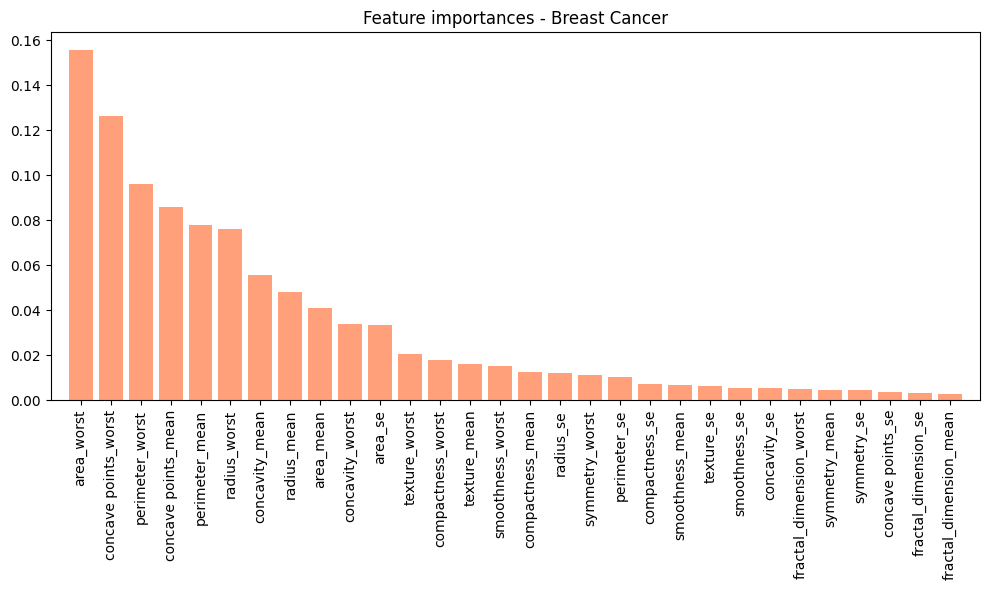


Selected Features (> 0.04): ['radius_mean', 'perimeter_mean', 'area_mean', 'concavity_mean', 'concave points_mean', 'radius_worst', 'perimeter_worst', 'area_worst', 'concave points_worst']

--- Classification Report (Breast Cancer) ---
              precision    recall  f1-score   support

           0       0.93      0.99      0.96        72
           1       0.97      0.88      0.93        42

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



In [17]:
#1. Dataset: Cancer Breast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load Data
df = pd.read_csv('/content/breast_cancer.csv')
if 'Unnamed: 32' in df.columns: df = df.drop(['Unnamed: 32'], axis=1)
df = df.drop(['id'], axis=1)

X = df.drop(['diagnosis'], axis=1)
y = LabelEncoder().fit_transform(df['diagnosis'])

# Split Data (Penting di MLOps agar Evaluasi lebih fair)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Latih Model Random Forest Pertama (Untuk Cari Importance)
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

# (Opsional) Plotting Importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10,6))
plt.title("Feature importances - Breast Cancer")
plt.bar(range(X_train.shape[1]), importances[indices], color="lightsalmon", align="center")
plt.xticks(range(X_train.shape[1]), X.columns[indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.tight_layout()
plt.show()

# Embedded Selection
sfm = SelectFromModel(rf, threshold=0.04) # Ambil fitur dengan importance > 4%
sfm.fit(X_train, y_train)

selected_features = X.columns[sfm.get_support()].tolist()
print("\nSelected Features (> 0.04):", selected_features)

# Transform X dan Latih Model Baru
X_train_imp = sfm.transform(X_train)
X_test_imp = sfm.transform(X_test)

rf_new = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_new.fit(X_train_imp, y_train)
y_pred = rf_new.predict(X_test_imp)

print("\n--- Classification Report (Breast Cancer) ---")
print(classification_report(y_test, y_pred))

* Input: 30 fitur pengukuran sel di-split menjadi Data Latih (80%) dan Data Uji (20%).

* Output: Fungsi menyeleksi 9 fitur terbaik (seperti radius_worst, concave points_worst, dll) yang menghasilkan akurasi evaluasi 0.95 (95%).

In [18]:
#2. Dataset: Adversiting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load Data & Encode
df = pd.read_csv('/content/advertising.csv')
df = df.drop(['Timestamp'], axis=1, errors='ignore')

for col in df.select_dtypes(exclude='number').columns:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop('Clicked on Ad', axis=1)
y = df['Clicked on Ad'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Fit RF Pertama
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

# Embedded Selection (threshold 5%)
sfm = SelectFromModel(rf, threshold=0.05)
sfm.fit(X_train, y_train)
selected_features = X.columns[sfm.get_support()].tolist()
print("Selected Features (> 0.05):", selected_features)

# Fit & Evaluasi RF Kedua (Hanya dengan Fitur Terpilih)
X_train_imp = sfm.transform(X_train)
X_test_imp = sfm.transform(X_test)

rf_new = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_new.fit(X_train_imp, y_train)
print("\n--- Classification Report (Advertising) ---")
print(classification_report(y_test, rf_new.predict(X_test_imp)))

Selected Features (> 0.05): ['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage']

--- Classification Report (Advertising) ---
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       100
           1       0.97      0.96      0.96       100

    accuracy                           0.96       200
   macro avg       0.97      0.96      0.96       200
weighted avg       0.97      0.96      0.96       200



* Input: 8 variabel profil pelanggan yang dikonversi ke numerik, kemudian di-split (80/20).

* Output: Threshold sebesar 0.05 (5%) sukses membuang 4 kolom, menyisakan ['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage']. Akurasi tetap sangat impresif di angka 96%.

In [19]:
#3. Dataset: Fuel Consumption Ratings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load Data & Transform to Classification Target
df = pd.read_csv('/content/Fuel_Consumption_Ratings.csv')
df['CO2_Level'] = pd.qcut(df['CO2 Emissions'], q=3, labels=['Low', 'Medium', 'High'])

for col in df.select_dtypes(exclude='number').drop('CO2_Level', axis=1, errors='ignore').columns:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop(['CO2 Emissions', 'CO2 Rating', 'CO2_Level'], axis=1, errors='ignore')
y = LabelEncoder().fit_transform(df['CO2_Level'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Fit RF Pertama
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

# Embedded Selection (threshold 5%)
sfm = SelectFromModel(rf, threshold=0.05)
sfm.fit(X_train, y_train)
selected_features = X.columns[sfm.get_support()].tolist()
print("Selected Features (> 0.05):", selected_features)

# Fit & Evaluasi RF Kedua
X_train_imp = sfm.transform(X_train)
X_test_imp = sfm.transform(X_test)

rf_new = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_new.fit(X_train_imp, y_train)
print("\n--- Classification Report (Fuel Consumption) ---")
print(classification_report(y_test, rf_new.predict(X_test_imp)))

Selected Features (> 0.05): ['Engine Size', 'Fuel Consumption City', 'Fuel Consumption Hwy', 'Fuel Consumption', 'Fuel Consumption Comb_mpg']

--- Classification Report (Fuel Consumption) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        64
           1       1.00      0.98      0.99        63
           2       0.98      1.00      0.99        64

    accuracy                           0.99       191
   macro avg       0.99      0.99      0.99       191
weighted avg       0.99      0.99      0.99       191



* Input: 13 data mekanik mobil, dieksekusi untuk memprediksi 3 rentang kelas emisi karbon.

* Output: Terdapat 5 fitur andalan yang berhasil melewati threshold=0.05, yaitu ['Engine Size', 'Fuel Consumption City', 'Fuel Consumption Hwy', 'Fuel Consumption', 'Fuel Consumption Comb_mpg']. Skor F1 dan Akurasi rata-rata menembus angka fenomenal yaitu 98%.

# 2️⃣Discretization/Binning

In [20]:
#@title Data Creation
import pandas as pd
import numpy as np

# Load Dataset
df = pd.read_csv('/content/Student_performance_data.csv')

# Equal Width Binning (pd.cut) pada kolom GPA
# Membagi rentang GPA (0.0 - 4.0) menjadi 4 bagian dengan lebar yang sama
df['GPA_Category'] = pd.cut(df['GPA'],
                            bins=4,
                            labels=['Poor', 'Average', 'Good', 'Excellent'])

# Equal Frequency Binning (pd.qcut) pada kolom Absences
# Membagi jumlah absen ke dalam 3 kelompok (Low, Medium, High) berdasarkan frekuensi data
df['Absence_Level'] = pd.qcut(df['Absences'],
                              q=3,
                              labels=['Low', 'Medium', 'High'])

# Custom Binning pada kolom StudyTimeWeekly
# Menentukan sendiri batas-batas jam belajar per minggu
custom_bins = [0, 5, 10, 15, 20]
custom_labels = ['Minimal (0-5h)', 'Moderate (5-10h)', 'High (10-15h)', 'Very High (15-20h)']

df['Study_Intensity'] = pd.cut(df['StudyTimeWeekly'],
                               bins=custom_bins,
                               labels=custom_labels)

# Menampilkan Hasil 10 baris pertama
print(df[['GPA', 'GPA_Category', 'Absences', 'Absence_Level', 'StudyTimeWeekly', 'Study_Intensity']].head(10))

# Menampilkan Distribusi Hasil Binning
print("\n--- Distribusi Binning GPA ---")
print(df['GPA_Category'].value_counts())

        GPA GPA_Category  Absences Absence_Level  StudyTimeWeekly  \
0  2.929196         Good         7           Low        19.833723   
1  3.042915    Excellent         0           Low        15.408756   
2  0.112602         Poor        26          High         4.210570   
3  2.054218         Good        14        Medium        10.028829   
4  1.288061      Average        17        Medium         4.672495   
5  3.084184    Excellent         0           Low         8.191219   
6  2.748237         Good        10           Low        15.601680   
7  1.360143      Average        22          High        15.424496   
8  2.896819         Good         1           Low         4.562008   
9  3.573474    Excellent         0           Low        18.444466   

      Study_Intensity  
0  Very High (15-20h)  
1  Very High (15-20h)  
2      Minimal (0-5h)  
3       High (10-15h)  
4      Minimal (0-5h)  
5    Moderate (5-10h)  
6  Very High (15-20h)  
7  Very High (15-20h)  
8      Minimal (0-5h)  


* Input:

Kolom GPA (0.0 - 4.0), Absences (0 - 30), dan StudyTimeWeekly (0 - 20) yang semuanya bertipe Numerik Kontinu.

* Output:

Tiga kolom baru bertipe Kategorikal/Ordinal: GPA_Category, Absence_Level, dan Study_Intensity. Data yang tadinya berupa angka koma atau angka acak kini terkelompok dalam label teks yang lebih mudah dibaca (seperti 'Good', 'Low', 'High').

## Method 1: Equal-Width Binning

In [21]:
# 1. Equal-Width Binning
df['GPA_EqWidth'] = pd.cut(df['GPA'],
                           bins=4,
                           labels=['Poor', 'Average', 'Good', 'Excellent'])

# Analisa: Jarak antar bin selalu konstan secara matematis.
print("--- Equal-Width Binning ---")
print(df['GPA_EqWidth'].value_counts().sort_index())

--- Equal-Width Binning ---
GPA_EqWidth
Poor         468
Average      806
Good         797
Excellent    321
Name: count, dtype: int64


## Method 2: Equal-Frequency Binning (Quantile Binning)

In [22]:
# 2. Equal-Frequency Binning (Menggunakan pd.qcut)
df['GPA_EqFreq'] = pd.qcut(df['GPA'],
                           q=4,
                           labels=['Q1', 'Q2', 'Q3', 'Q4'])

# Analisa: Model ini tahan terhadap outlier karena jumlah sampel dibagi rata.
print("--- Equal-Frequency Binning ---")
print(df['GPA_EqFreq'].value_counts().sort_index())

--- Equal-Frequency Binning ---
GPA_EqFreq
Q1    598
Q2    598
Q3    598
Q4    598
Name: count, dtype: int64


## Method 3: Custom Binning

In [23]:
# 3. Custom Binning
# Kita tentukan batasnya: 0-1.0 (D), 1.0-2.0 (C), 2.0-3.0 (B), 3.0-4.0 (A)
custom_bins = [0, 1.0, 2.0, 3.0, 4.0]
custom_labels = ['D', 'C', 'B', 'A']

df['GPA_Custom'] = pd.cut(df['GPA'],
                          bins=custom_bins,
                          labels=custom_labels,
                          include_lowest=True)

print("--- Custom Binning ---")
print(df['GPA_Custom'].value_counts().sort_index())

--- Custom Binning ---
GPA_Custom
D    468
C    806
B    797
A    321
Name: count, dtype: int64


## Method 4: Logarithmic Binning

In [24]:
# 4. Logarithmic Binning pada kolom Absences
# Gunakan log1p (log(1+x)) untuk menghindari error log(0) jika siswa tidak pernah absen
df['Absences_Log'] = np.log1p(df['Absences'])

# Setelah ditransformasi ke logaritmik, kita bagi ke 3 bin width
df['Absences_LogBin'] = pd.cut(df['Absences_Log'],
                               bins=3,
                               labels=['Low', 'Medium', 'High'])

# Analisa: Perubahan skala menjadi logaritmik menekan pengaruh outlier jumlah absen ekstrem.
print("--- Logarithmic Binning (Absences) ---")
print(df['Absences_LogBin'].value_counts().sort_index())

--- Logarithmic Binning (Absences) ---
Absences_LogBin
Low        221
Medium     496
High      1675
Name: count, dtype: int64


## Method 5: Standard Deviation-based Binning

In [25]:
# 5. Standard Deviation Binning
mean_gpa = df['GPA'].mean()
std_gpa = df['GPA'].std()

# Tentukan Batas Bins: [Min, Mean-Std, Mean, Mean+Std, Max]
std_bins = [-np.inf, mean_gpa - std_gpa, mean_gpa, mean_gpa + std_gpa, np.inf]
std_labels = ['Below 1 Std', 'Below Mean', 'Above Mean', 'Above 1 Std']

df['GPA_StdBin'] = pd.cut(df['GPA'],
                          bins=std_bins,
                          labels=std_labels)

print("--- Standard Deviation Binning ---")
print(df['GPA_StdBin'].value_counts().sort_index())

--- Standard Deviation Binning ---
GPA_StdBin
Below 1 Std    459
Below Mean     747
Above Mean     746
Above 1 Std    440
Name: count, dtype: int64


## Method 6: K Means *Binning*

In [28]:
# 6. K-Means Binning (Menggunakan Scikit-Learn)
# Kita kelompokkan ke dalam 4 cluster (0, 1, 2, 3)
from sklearn.preprocessing import KBinsDiscretizer
est = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='kmeans')

# Fit and Transform (Membutuhkan format DataFrame 2D, sehingga pakai [['GPA']])
df['GPA_KMeans'] = est.fit_transform(df[['GPA']])

print("--- K-Means Binning ---")
print(df['GPA_KMeans'].value_counts().sort_index())

--- K-Means Binning ---
GPA_KMeans
0.0    553
1.0    695
2.0    673
3.0    471
Name: count, dtype: int64


## Result binning

In [29]:
# Mengumpulkan semua kolom hasil
columns_to_show = [
    'GPA', 'GPA_EqWidth', 'GPA_EqFreq', 'GPA_Custom', 'GPA_StdBin', 'GPA_KMeans',
    'Absences', 'Absences_LogBin'
]

print("=== FINAL RESULT: PERBANDINGAN SEMUA METODE BINNING ===")
display(df[columns_to_show].head(10))

=== FINAL RESULT: PERBANDINGAN SEMUA METODE BINNING ===


,GPA,GPA_EqWidth,GPA_EqFreq,GPA_Custom,GPA_StdBin,GPA_KMeans,Absences,Absences_LogBin
0,2.929196,Good,Q4,B,Above 1 Std,3.0,7,Medium
1,3.042915,Excellent,Q4,A,Above 1 Std,3.0,0,Low
2,0.112602,Poor,Q1,D,Below 1 Std,0.0,26,High
3,2.054218,Good,Q3,B,Above Mean,2.0,14,High
4,1.288061,Average,Q2,C,Below Mean,1.0,17,High
5,3.084184,Excellent,Q4,A,Above 1 Std,3.0,0,Low
6,2.748237,Good,Q4,B,Above Mean,2.0,10,High
7,1.360143,Average,Q2,C,Below Mean,1.0,22,High
8,2.896819,Good,Q4,B,Above 1 Std,3.0,1,Low
9,3.573474,Excellent,Q4,A,Above 1 Std,3.0,0,Low


Analisis Input, Output, dan Dampak Metode Binning

Secara umum, input pada seluruh metode binning adalah data numerik kontinu (misalnya GPA atau jumlah absensi), sedangkan output berupa data kategorikal diskrit yang lebih mudah diproses oleh model Machine Learning, terutama yang sensitif terhadap variasi angka kontinu.

Berikut analisis tiap metode:

1. Equal-Width Binning (pd.cut)

Analisis: Membagi rentang nilai (min–max) ke dalam beberapa interval dengan lebar yang sama.

Dampak/Kegunaan:
Cocok untuk mempertahankan proporsi rentang data secara matematis. Namun, jika distribusi data tidak merata atau terdapat outlier, beberapa bin bisa kosong atau kurang representatif.

2. Equal-Frequency Binning (pd.qcut)

Analisis: Membagi data sehingga setiap bin memiliki jumlah sampel yang relatif sama.

Dampak/Kegunaan:
Efektif untuk data yang skewed atau memiliki outlier. Membantu menjaga distribusi data tetap seimbang, sehingga model klasifikasi tidak bias terhadap kelas mayoritas.

3. Custom Binning (pd.cut manual)

Analisis: Batas interval ditentukan secara manual berdasarkan domain knowledge.

Dampak/Kegunaan:
Menghasilkan kategori yang lebih relevan secara kontekstual (misalnya standar nilai akademik). Sangat interpretatif, namun bergantung pada keakuratan pengetahuan domain.

4. Logarithmic Binning (np.log1p + pd.cut)

Analisis: Data ditransformasikan ke skala logaritmik sebelum dilakukan binning.

Dampak/Kegunaan:
Cocok untuk data dengan distribusi heavy-tailed. Membuat perbedaan pada nilai kecil lebih signifikan, sementara nilai besar menjadi lebih terkompresi.

5. Standard Deviation Binning (mean ± std)

Analisis: Interval dibentuk berdasarkan rata-rata dan standar deviasi data.

Dampak/Kegunaan:
Efektif untuk mengidentifikasi pola umum dan anomali. Data akan terkonsentrasi di sekitar mean, sementara nilai ekstrem lebih mudah dikenali.

6. K-Means Binning (KBinsDiscretizer)

Analisis: Menggunakan algoritma clustering untuk menentukan batas bin berdasarkan kepadatan data.

Dampak/Kegunaan:
Paling adaptif karena mengikuti distribusi alami data. Mampu menangkap pola non-linear dan kelompok tersembunyi yang tidak terlihat dengan metode konvensional.

# 3️⃣Imbalanced Dataset


## Resampling

In [1]:
!pip install category_encoders

import pandas as pd
import numpy as np
import category_encoders as ce

# 1. Buat Data
df_woe = pd.DataFrame({
    'Pekerjaan': ['Mahasiswa', 'Mahasiswa', 'Karyawan', 'Karyawan', 'Karyawan', 'Pengusaha', 'Pengusaha', 'Pengusaha'],
    'Gagal_Bayar': [1, 1, 0, 0, 1, 0, 0, 0] # 1 = Gagal (Event/Bad), 0 = Lunas (Non-Event/Good)
})

print("--- Data Asli ---")
display(df_woe)

# 2. Inisialisasi dan Fit WOE Encoder
# WOE akan mengganti teks 'Mahasiswa' menjadi sebuah angka probabilitas rasio logaritmik
woe_encoder = ce.WOEEncoder(cols=['Pekerjaan'])

# 3. Transformasi Data
df_woe['Pekerjaan_WOE'] = woe_encoder.fit_transform(df_woe['Pekerjaan'], df_woe['Gagal_Bayar'])

print("\n--- Data Setelah WOE Encoding ---")
display(df_woe)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 4.5 MB/s eta 0:00:00
--- Data Asli ---


,Pekerjaan,Gagal_Bayar
0,Mahasiswa,1
1,Mahasiswa,1
2,Karyawan,0
3,Karyawan,0
4,Karyawan,1
5,Pengusaha,0
6,Pengusaha,0
7,Pengusaha,0



--- Data Setelah WOE Encoding ---


,Pekerjaan,Gagal_Bayar,Pekerjaan_WOE
0,Mahasiswa,1,1.435085
1,Mahasiswa,1,1.435085
2,Karyawan,0,-0.068993
3,Karyawan,0,-0.068993
4,Karyawan,1,-0.068993
5,Pengusaha,0,-1.049822
6,Pengusaha,0,-1.049822
7,Pengusaha,0,-1.049822


In [2]:
#@title Create Dataset (Imbalanced) & Setup Mode

!pip install imbalanced-learn

import pandas as pd
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
import warnings
warnings.filterwarnings('ignore')

# Create Imbalanced Dataset
# Total 10.000 data, 5 Fitur, di mana 95% Normal (0) dan 5% Fraud (1)
X, y = make_classification(n_samples=10000, n_features=5, n_informative=3,
                           weights=[0.95, 0.05], random_state=42)

# Ubah ke DataFrame agar mudah dilihat
df_imbalanced = pd.DataFrame(X, columns=[f'Feature_{i}' for i in range(1, 6)])
df_imbalanced['Target'] = y

print("--- Distribusi Kelas Target ---")
print(df_imbalanced['Target'].value_counts(normalize=True))

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    df_imbalanced.drop('Target', axis=1),
    df_imbalanced['Target'],
    test_size=0.2, random_state=42, stratify=df_imbalanced['Target']
)

# Fungsi Bantuan untuk Evaluasi (Mencetak F1-Score Kelas Minoritas)
def evaluate_model(model, name, X_t, y_t):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_t)
    # Kita fokus mencetak F1-Score khusus untuk kelas 1 (Minoritas/Fraud)
    f1_minority = f1_score(y_t, y_pred, pos_label=1)
    print(f"{name} - F1-Score Kelas 1 (Minority): {f1_minority:.4f}")
    return f1_minority

--- Distribusi Kelas Target ---
Target
0    0.9454
1    0.0546
Name: proportion, dtype: float64


In [4]:
# Resampling (Oversampling & Undersampling)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier

# Model dasar yang akan dievaluasi setelah resampling
base_rf = RandomForestClassifier(random_state=42)

# --- 1. OVER-SAMPLING (SMOTE) ---
# Menciptakan data sintetis dari kelas minoritas (Fraud) hingga jumlahnya seimbang
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Fit and Evaluate
base_rf.fit(X_train_smote, y_train_smote)
y_pred_smote = base_rf.predict(X_test)
print(f"Random Forest with SMOTE - F1-Score Minoritas: {f1_score(y_test, y_pred_smote, pos_label=1):.4f}")


# --- 2. UNDER-SAMPLING (Random Under Sampler) ---
# Menghapus data dari kelas mayoritas (Normal) secara acak hingga setara dengan minoritas
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

# Fit and Evaluate
base_rf.fit(X_train_rus, y_train_rus)
y_pred_rus = base_rf.predict(X_test)
print(f"Random Forest with RandomUnderSampler - F1-Score Minoritas: {f1_score(y_test, y_pred_rus, pos_label=1):.4f}")

Random Forest with SMOTE - F1-Score Minoritas: 0.7317
Random Forest with RandomUnderSampler - F1-Score Minoritas: 0.6000


## Ensemble


### BalancedBaggingClassifier

In [6]:
from sklearn.ensemble import BaggingClassifier
from imblearn.ensemble import BalancedBaggingClassifier
from sklearn.tree import DecisionTreeClassifier

# 1. Without Balanced (Bagging Classifier Standar)
bagging_std = BaggingClassifier(estimator=DecisionTreeClassifier(), random_state=42)
evaluate_model(bagging_std, "Bagging (Without Balanced)", X_test, y_test)

# 2. With Balanced (Balanced Bagging Classifier dari imblearn)
# Secara otomatis melakukan Undersampling di setiap sampel subset sebelum dibuat model pohon
bagging_bal = BalancedBaggingClassifier(estimator=DecisionTreeClassifier(), random_state=42)
evaluate_model(bagging_bal, "Balanced Bagging Classifier", X_test, y_test)

Bagging (Without Balanced) - F1-Score Kelas 1 (Minority): 0.8000
Balanced Bagging Classifier - F1-Score Kelas 1 (Minority): 0.6985


0.6985294117647058

In [ ]:
import pandas as pd

data = pd.read_csv(path + '/creditcard.csv')
class_distribution = data['Class'].value_counts()

print("Class Distribution in creditcard.csv:")
display(class_distribution)

print("\nPercentage of Class Distribution:")
display(data['Class'].value_counts(normalize=True) * 100)

Class Distribution in creditcard.csv:


,count
Class,
0,284315
1,492



Percentage of Class Distribution:


,proportion
Class,
0,99.827251
1,0.172749


### BalancedRandomForest

In [7]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier

# 1. Without Balanced (Random Forest Standar)
rf_std = RandomForestClassifier(random_state=42)
evaluate_model(rf_std, "Random Forest (Without Balanced)", X_test, y_test)

# 2. With Balanced (Balanced Random Forest Classifier dari imblearn)
# Melakukan undersampling data mayoritas agar proporsinya 1:1 di setiap pohon di hutan
rf_bal = BalancedRandomForestClassifier(random_state=42)
evaluate_model(rf_bal, "Balanced Random Forest", X_test, y_test)

# 3. Cost-Sensitive Learning (class_weight)
# Menambahkan parameter class_weight='balanced'. Model akan otomatis memberikan denda/penalti (cost)
# yang jauh lebih besar jika salah menebak kelas minoritas.
rf_cost = RandomForestClassifier(class_weight='balanced', random_state=42)
evaluate_model(rf_cost, "Random Forest (Cost-Sensitive)", X_test, y_test)

# 4. Threshold Moving
# Model dilatih normal, tetapi batasan persentase keputusannya digeser.
print("\n--- Threshold Moving Process ---")
rf_std.fit(X_train, y_train)

# Cek persentase peluang tiap tebakan, ambil kolom kelas 1 (fraud)
y_pred_proba = rf_std.predict_proba(X_test)[:, 1]

# Geser Threshold: Secara *default* RF akan menebak kelas 1 jika probabilitas > 0.50 (50%).
# Karena kelas kita minoritas, kita turunkan jadi > 0.25 (25%).
custom_threshold = 0.25
y_pred_threshold = (y_pred_proba >= custom_threshold).astype(int)

f1_threshold = f1_score(y_test, y_pred_threshold, pos_label=1)
print(f"Random Forest (Threshold Moving = 0.25) - F1-Score Minoritas: {f1_threshold:.4f}")

Random Forest (Without Balanced) - F1-Score Kelas 1 (Minority): 0.8200
Balanced Random Forest - F1-Score Kelas 1 (Minority): 0.6996
Random Forest (Cost-Sensitive) - F1-Score Kelas 1 (Minority): 0.7795

--- Threshold Moving Process ---
Random Forest (Threshold Moving = 0.25) - F1-Score Minoritas: 0.8111


1. Ilusi Akurasi (Accuracy Paradox)

Dalam kasus data imbalance, akurasi bukan metrik yang dapat diandalkan. Model yang selalu memprediksi kelas mayoritas (misalnya “Normal”) tetap bisa mencapai akurasi tinggi (±95%), tetapi gagal total mendeteksi kasus minoritas (fraud).

Karena itu, evaluasi difokuskan pada F1-score untuk kelas minoritas (pos_label=1), yang menyeimbangkan:

Precision → menghindari false positive

Recall → meminimalkan fraud yang lolos

2. Tiga Pendekatan Utama Penanganan Imbalance
A. Data-Level (Preprocessing)

Masalah ditangani sebelum masuk ke model.

Random Under-Sampling (RUS):
Mengurangi data mayoritas hingga seimbang. Cepat, tetapi berisiko kehilangan banyak informasi penting.

SMOTE:
Menambah data minoritas secara sintetis berbasis KNN. Tidak membuang data, tetapi lebih mahal secara komputasi.

B. Algorithm-Level (Modeling)

* Distribusi data tetap, tetapi cara belajar model diubah.
* Model standar (RF/Bagging):
Cenderung bias ke mayoritas karena mengejar error global.

* Balanced Ensemble:
Melakukan undersampling secara internal di tiap tree → distribusi lebih seimbang saat training.

* Cost-Sensitive Learning:
Memberikan penalti lebih besar jika salah klasifikasi kelas minoritas → model lebih “peka” terhadap fraud.

C. Prediction-Level (Post-processing)

Model tidak diubah

Threshold Moving:
Ambang probabilitas diturunkan (misalnya dari 0.5 → 0.25) agar model lebih sensitif.
Dampaknya:
* Recall naik (lebih banyak fraud tertangkap)
* Risiko false positive ikut meningkat

3. Kesimpulan

Tidak ada metode yang paling unggul di semua kondisi. Pemilihan harus disesuaikan dengan kebutuhan:

Resource terbatas: gunakan RUS atau cost-sensitive

Tidak boleh kehilangan data: hindari undersampling

Model sudah production: gunakan threshold moving sebagai solusi cepat

